In [3]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression

ZIP_DIR = Path("data/zips")
KLINES_COLUMNS = [
    "Open time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close time",
    "Quote asset volume",
    "Number of trades",
    "Taker buy base asset volume",
    "Taker buy quote asset volume",
    "Ignore",
]


def load_1m_zip(symbol, year=2025):
    frames = []
    for zp in sorted(ZIP_DIR.glob(f"{symbol}-1m-{year}-*.zip")):
        with zipfile.ZipFile(zp) as zf:
            with zf.open(zf.namelist()[0]) as f:
                df = pd.read_csv(f, header=None, names=KLINES_COLUMNS)
        sample = df["Open time"].iloc[0]
        unit = "us" if sample > 1e15 else "ms"
        df["time"] = pd.to_datetime(df["Open time"], unit=unit, utc=True).dt.tz_convert(
            None
        )
        df["close"] = df["Close"].astype(float)
        frames.append(df[["time", "close"]])
    return (
        pd.concat(frames, ignore_index=True).sort_values("time").reset_index(drop=True)
    )


rad = load_1m_zip("RADUSDT")
usdc = load_1m_zip("USDCUSDT")

# Merge: pair price = USDC/RAD = usdc_price / rad_price
data = pd.merge(
    usdc.rename(columns={"close": "usdc"}),
    rad.rename(columns={"close": "rad"}),
    on="time",
)
data["close"] = data["usdc"] / data["rad"]  # USDC/RAD ratio
data["week"] = data["time"].dt.to_period("W")
print(f"Loaded {len(data)} rows, {data['time'].min()} — {data['time'].max()}")

Loaded 525600 rows, 2025-01-01 00:00:00 — 2025-12-31 23:59:00


In [4]:
def calculate_slope(group):
    X = np.arange(len(group)).reshape(-1, 1)
    y = np.log(group["close"].values)
    return LinearRegression().fit(X, y).coef_[0]


def calculate_std(group):
    return np.std(np.diff(np.log(group["close"].values)))


records = []
for week, group in data.groupby("week"):
    if len(group) < 100:  # skip partial weeks
        continue
    records.append(
        {
            "week": week,
            "slope": calculate_slope(group),
            "std": calculate_std(group),
            "start": group["time"].iloc[0],
            "end": group["time"].iloc[-1],
        }
    )

weekly = pd.DataFrame(records)
print(weekly[["week", "slope", "std"]].to_string())

                     week         slope       std
0   2024-12-30/2025-01-05 -1.025719e-05  0.001111
1   2025-01-06/2025-01-12  1.517917e-05  0.001475
2   2025-01-13/2025-01-19  1.217314e-06  0.001638
3   2025-01-20/2025-01-26  4.456045e-07  0.001611
4   2025-01-27/2025-02-02 -7.950309e-07  0.002930
5   2025-02-03/2025-02-09  8.867384e-06  0.003242
6   2025-02-10/2025-02-16 -4.534578e-06  0.001516
7   2025-02-17/2025-02-23  1.032895e-06  0.001262
8   2025-02-24/2025-03-02 -1.074577e-06  0.001362
9   2025-03-03/2025-03-09  9.565344e-06  0.001957
10  2025-03-10/2025-03-16 -1.042877e-05  0.004636
11  2025-03-17/2025-03-23  3.517286e-06  0.001782
12  2025-03-24/2025-03-30  7.244500e-06  0.001532
13  2025-03-31/2025-04-06  7.350925e-06  0.001675
14  2025-04-07/2025-04-13 -9.897840e-06  0.001779
15  2025-04-14/2025-04-20 -4.545758e-06  0.001554
16  2025-04-21/2025-04-27 -8.614396e-06  0.001516
17  2025-04-28/2025-05-04  5.272885e-06  0.001162
18  2025-05-05/2025-05-11 -1.499873e-05  0.001412


In [5]:
# Apply market_type_definition (same logic as cex_prices_visualization.ipynb)
def market_type_definition(df):
    perc_25 = np.percentile(df["slope"], 25)
    perc_75 = np.percentile(df["slope"], 75)
    middle = df[(df["slope"] > perc_25) & (df["slope"] < perc_75)]
    mid_std = np.percentile(middle["std"], 50)

    df = df.copy()
    df["market_type"] = None
    df.loc[df["slope"] >= perc_75, "market_type"] = "bull_market"
    df.loc[df["slope"] <= perc_25, "market_type"] = "bear_market"
    df.loc[(df["std"] >= mid_std) & df["market_type"].isna(), "market_type"] = (
        "volatile_market"
    )
    df.loc[(df["std"] < mid_std) & df["market_type"].isna(), "market_type"] = (
        "calm_market"
    )
    return df, perc_25, perc_75, mid_std


weekly, p25, p75, mid_std = market_type_definition(weekly)
print(weekly[["week", "slope", "std", "market_type"]].to_string())

                     week         slope       std      market_type
0   2024-12-30/2025-01-05 -1.025719e-05  0.001111      bear_market
1   2025-01-06/2025-01-12  1.517917e-05  0.001475      bull_market
2   2025-01-13/2025-01-19  1.217314e-06  0.001638  volatile_market
3   2025-01-20/2025-01-26  4.456045e-07  0.001611  volatile_market
4   2025-01-27/2025-02-02 -7.950309e-07  0.002930  volatile_market
5   2025-02-03/2025-02-09  8.867384e-06  0.003242      bull_market
6   2025-02-10/2025-02-16 -4.534578e-06  0.001516      bear_market
7   2025-02-17/2025-02-23  1.032895e-06  0.001262      calm_market
8   2025-02-24/2025-03-02 -1.074577e-06  0.001362      calm_market
9   2025-03-03/2025-03-09  9.565344e-06  0.001957      bull_market
10  2025-03-10/2025-03-16 -1.042877e-05  0.004636      bear_market
11  2025-03-17/2025-03-23  3.517286e-06  0.001782  volatile_market
12  2025-03-24/2025-03-30  7.244500e-06  0.001532      calm_market
13  2025-03-31/2025-04-06  7.350925e-06  0.001675      bull_ma

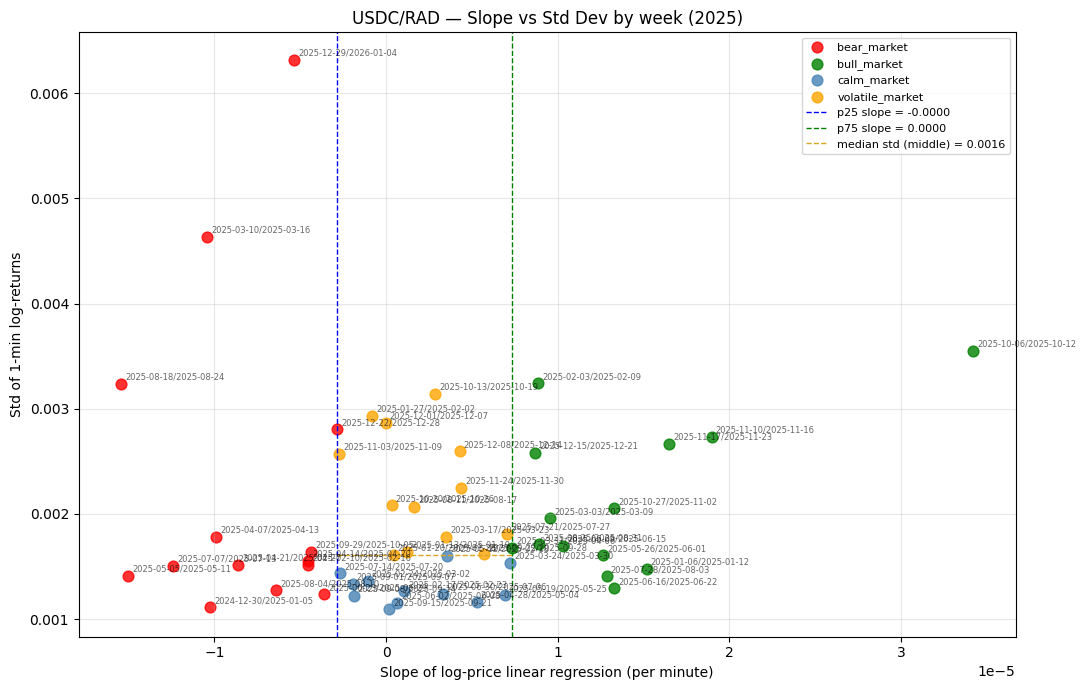

In [6]:
# Scatter: Slope vs Std, coloured by market type
colors = {
    "bull_market": "green",
    "bear_market": "red",
    "volatile_market": "orange",
    "calm_market": "steelblue",
}

fig, ax = plt.subplots(figsize=(11, 7))

for mtype, grp in weekly.groupby("market_type"):
    ax.scatter(grp["slope"], grp["std"], c=colors[mtype], label=mtype, alpha=0.8, s=60)
    for _, row in grp.iterrows():
        ax.annotate(
            str(row["week"]),
            (row["slope"], row["std"]),
            fontsize=6,
            alpha=0.6,
            textcoords="offset points",
            xytext=(3, 3),
        )

# Boundary lines
ax.axvline(
    p25, color="blue", linestyle="--", linewidth=1, label=f"p25 slope = {p25:.4f}"
)
ax.axvline(
    p75, color="green", linestyle="--", linewidth=1, label=f"p75 slope = {p75:.4f}"
)
ax.hlines(
    mid_std,
    p25,
    p75,
    colors="goldenrod",
    linestyles="--",
    linewidth=1,
    label=f"median std (middle) = {mid_std:.4f}",
)

ax.set_xlabel("Slope of log-price linear regression (per minute)")
ax.set_ylabel("Std of 1-min log-returns")
ax.set_title("USDC/RAD — Slope vs Std Dev by week (2025)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Show best representative week per market type (closest to centroid)
print("Best representative weeks per market type:\n")
for mtype in ["bull_market", "bear_market", "volatile_market", "calm_market"]:
    grp = weekly[weekly["market_type"] == mtype]
    # pick the one closest to the group centroid
    cx, cy = grp["slope"].mean(), grp["std"].mean()
    dist = np.sqrt((grp["slope"] - cx) ** 2 + (grp["std"] - cy) ** 2)
    best = grp.loc[dist.idxmin()]
    print(
        f"  {mtype:20s}: week={best['week']}  slope={best['slope']:.5f}  std={best['std']:.5f}"
    )
    print(f"    -> {best['start'].date()} — {best['end'].date()}")

Best representative weeks per market type:

  bull_market         : week=2025-10-27/2025-11-02  slope=0.00001  std=0.00205
    -> 2025-10-27 — 2025-11-02
  bear_market         : week=2025-04-07/2025-04-13  slope=-0.00001  std=0.00178
    -> 2025-04-07 — 2025-04-13
  volatile_market     : week=2025-11-24/2025-11-30  slope=0.00000  std=0.00225
    -> 2025-11-24 — 2025-11-30
  calm_market         : week=2025-09-01/2025-09-07  slope=-0.00000  std=0.00134
    -> 2025-09-01 — 2025-09-07
